## Part 1: Load and Explore the Fashion-MNIST Dataset

Fashion-MNIST is a dataset of grayscale images belonging to 10 different clothing and footwear categories. Each image has a size of 28 × 28 pixels.

The dataset is divided into training and test sets. The training data is used to train the CNN models, while the test data is used to evaluate their performance on unseen images.

The dataset is loaded using TensorFlow/Keras, and the class names are defined to map the numerical labels to their corresponding categories.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Display the shapes of the datasets
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

# Define class names
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# Display number of classes
print("Number of classes:", len(class_names))

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10


### Dataset Shape

The loaded dataset contains 60,000 training images and 10,000 test images. Each image has dimensions of 28 × 28 pixels and is grayscale.

The training labels and test labels contain one class label for each corresponding image.

The dataset contains 10 different classes:

- T-shirt/top
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot

### Visualizing Sample Images from Each Class

To understand the Fashion-MNIST dataset visually, one sample image from each of the 10 classes is displayed below. Each image is labeled with its corresponding class name.

This helps us observe the visual differences and similarities between the different clothing and footwear categories before applying preprocessing and training the CNN models.

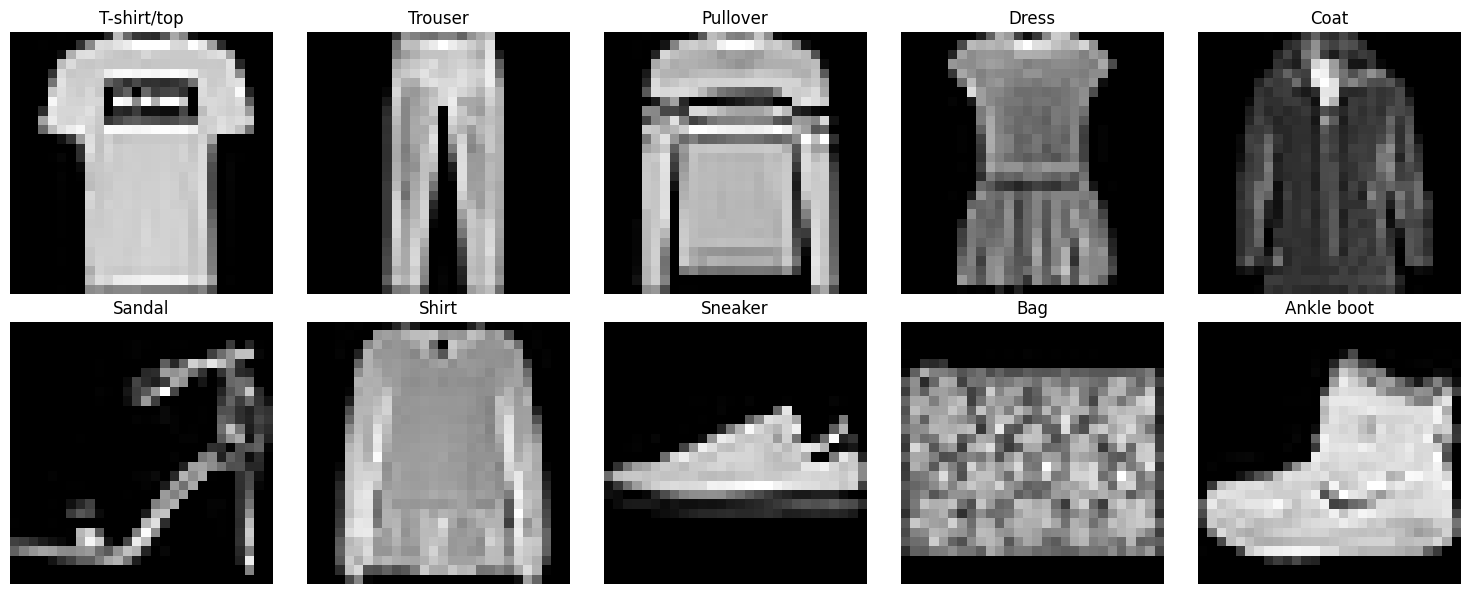

In [5]:
# Display one sample image from each class

plt.figure(figsize=(15, 6))

for class_id in range(10):
    # Find the first image belonging to the current class
    index = np.where(y_train == class_id)[0][0]
    
    # Display the image
    plt.subplot(2, 5, class_id + 1)
    plt.imshow(x_train[index], cmap="gray")
    plt.title(class_names[class_id])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Normalizing Image Pixel Values

The original Fashion-MNIST pixel values range from 0 to 255, where 0 represents black and higher values represent lighter shades.

To make the input values more suitable for neural network training, the pixel values are normalized to the range 0 to 1 by dividing each pixel value by 255.

Normalization puts the input features on a smaller and consistent scale, which helps the neural network train more efficiently and stably.

In [6]:
# Normalize pixel values from 0-255 to 0-1

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [7]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


### Normalization Result

The minimum pixel value after normalization is 0.0 and the maximum is 1.0. This confirms that the original pixel values, which ranged from 0 to 255, have been successfully scaled to the range 0 to 1.

This normalized representation provides smaller and consistently scaled input values for the CNN, helping the neural network train more efficiently and stably.

### Reshaping Images for CNN Input

The Fashion-MNIST images are originally stored with the shape `(number of images, 28, 28)`. Since the images are grayscale, a channel dimension of 1 must be added so that they have the four-dimensional structure expected by a 2D convolutional layer.

The images are therefore reshaped to `(number of images, 28, 28, 1)`, where the dimensions represent the number of images, height, width, and number of channels respectively.

In [8]:
# Add the channel dimension for CNN input

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Check the new shapes
print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)

x_train shape: (60000, 28, 28, 1)
x_test shape : (10000, 28, 28, 1)


### Reshaping Result

The training images now have the shape `(60000, 28, 28, 1)` and the test images have the shape `(10000, 28, 28, 1)`.

The four dimensions represent:

- Number of images
- Image height
- Image width
- Number of channels

Since Fashion-MNIST contains grayscale images, the number of channels is 1. The reshaped data is now in the appropriate format for processing with `Conv2D` layers.

### Why is Normalization Required for Image Data?

Normalization scales the original pixel values from the range 0–255 to the range 0–1. This provides the neural network with smaller and consistently scaled input values.

Normalized inputs help the CNN train more efficiently and stably, making the optimization process easier compared with using the original 0–255 pixel values.

### Why Do CNNs Require Reshaped Image Inputs?

CNNs process images using spatial dimensions such as height and width, along with a channel dimension. The original Fashion-MNIST images have the shape `(28, 28)`, which represents height and width but does not explicitly include the image channel.

Since Fashion-MNIST images are grayscale, a channel dimension of 1 is added, changing the shape to `(28, 28, 1)` for each image. For the complete training and test datasets, the shapes become `(60000, 28, 28, 1)` and `(10000, 28, 28, 1)` respectively.

This format allows the images to be used as input to `Conv2D` layers.